### Setup

In [1]:
import sys
import os
sys.path.append("../")
sys.path.append("../..")

In [2]:
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from scale_rl.common.wandb_utils import *

In [4]:
from color import METHOD_COLORS, METHOD_BOUNDARY_COLORS, BORDER_GRAY

In [5]:
from scale_rl.envs.humanoid_bench import HB_LOCOMOTION_NOHAND, HB_SUCCESS_SCORE, HB_RANDOM_SCORE

def replace_underbar_to_hypen(env_name_list):
    for idx in range(len(env_name_list)):
        env_name_list[idx] = env_name_list[idx].replace('_', '-')
    return env_name_list

def replace_underbar_to_hypen_dict(env_name_dict):
    _new_dict = {}
    for k, v in env_name_dict.items():
        _new_dict[k.replace('_', '-')] = v
    return _new_dict

In [6]:
HB_LOCOMOTION_NOHAND = replace_underbar_to_hypen(HB_LOCOMOTION_NOHAND)
HB_SUCCESS_SCORE = replace_underbar_to_hypen_dict(HB_SUCCESS_SCORE)
HB_RANDOM_SCORE = replace_underbar_to_hypen_dict(HB_RANDOM_SCORE)

# Remove manipulation & with-hand tasks
HB_SUCCESS_SCORE = {k: v for k, v in HB_SUCCESS_SCORE.items() if k in HB_LOCOMOTION_NOHAND}
HB_RANDOM_SCORE = {k: v for k, v in HB_RANDOM_SCORE.items() if k in HB_LOCOMOTION_NOHAND}

HB_STEPS = 1000000 # 1M

In [7]:
def normalize_score_with_random_and_base_score(
    df: pd.DataFrame, random_score_dict: dict, base_score_dict: dict
) -> pd.DataFrame:
    """
    Normalize the 'value' column based on random and base scores.
        normalized_value = (value - random_score) / (base_score - random_score)

    Args:
    - df (pd.DataFrame): DataFrame with 'env_name' and 'value' columns.
    - random_score_dict (dict): Mapping of 'env_name' to random scores.
    - base_score_dict (dict): Mapping of 'env_name' to base scores.

    Returns:
    - pd.DataFrame: DataFrame with an added 'normalized_value' column.
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_normalized = df.copy()

    # Define a function to normalize a single value
    def normalize_value(row):
        env_name = row["env_name"]
        value = row["value"]
        base_score = base_score_dict[env_name]
        random_score = random_score_dict[env_name]

        return (value - random_score) / (base_score - random_score)

    # Apply the normalization function to each row
    df_normalized["value"] = df_normalized.apply(normalize_value, axis=1)

    return df_normalized

### Load Simba+ & SimbaV2

In [8]:
entity = 'draftrec'
project_name = 'Simba_2501'
run_exp_names_to_analysis_exp_names = {
    'hypersimba_hb_metrics': 'SimbaV2',
    'simba_hb_metrics': 'Simba',
}
run_exp_names = list(run_exp_names_to_analysis_exp_names.keys())
metrics = ['avg_return', 'avg_estimate_q', 'avg_discounted_return', 'critic/pnorm_total', 'critic/gnorm_total', 'critic/effective_pnorm_total', 'critic/effective_gnorm_total', 'critic/effective_lr_total',  'critic/effective_fnorm_total']

In [9]:
# Load from wandb
runs = collect_runs(entity=entity, project_name=project_name) 
filtered_runs = filter_runs(runs, exp_names = run_exp_names)
wandb_df = convert_runs_to_dataframe(
    runs = filtered_runs, 
    run_exp_name_to_analysis_exp_name=run_exp_names_to_analysis_exp_names
)
wandb_df = wandb_df[wandb_df.apply(lambda row: 'finished' in str(row['run']), axis=1)]

  0%|          | 0/2103 [00:00<?, ?it/s]

  0%|          | 0/74 [00:00<?, ?it/s]

In [10]:
eval_df = convert_wandb_df_to_eval_df(wandb_df, metrics)
eval_df

  0%|          | 0/64 [00:00<?, ?it/s]

,exp_name,env_name,seed,metric,env_step,value
0,SimbaV2,h1-sit_hard-v0,4000,avg_return,0.0,3.933272
1,SimbaV2,h1-sit_hard-v0,4000,avg_return,100000.0,46.808514
2,SimbaV2,h1-sit_hard-v0,4000,avg_return,200000.0,681.343321
3,SimbaV2,h1-sit_hard-v0,4000,avg_return,300000.0,728.321362
4,SimbaV2,h1-sit_hard-v0,4000,avg_return,400000.0,748.896331
...,...,...,...,...,...,...
6178,SimbaV2,h1-walk-v0,0,critic/effective_fnorm_total,600000.0,1.000000
6179,SimbaV2,h1-walk-v0,0,critic/effective_fnorm_total,700000.0,1.000000
6180,SimbaV2,h1-walk-v0,0,critic/effective_fnorm_total,800000.0,1.000000
6181,SimbaV2,h1-walk-v0,0,critic/effective_fnorm_total,900000.0,1.000000


In [11]:
eval_df['env_name'] = eval_df['env_name'].str.replace('_', '-')
eval_df = eval_df[eval_df["env_name"].isin(HB_LOCOMOTION_NOHAND)]
eval_df

,exp_name,env_name,seed,metric,env_step,value
0,SimbaV2,h1-sit-hard-v0,4000,avg_return,0.0,3.933272
1,SimbaV2,h1-sit-hard-v0,4000,avg_return,100000.0,46.808514
2,SimbaV2,h1-sit-hard-v0,4000,avg_return,200000.0,681.343321
3,SimbaV2,h1-sit-hard-v0,4000,avg_return,300000.0,728.321362
4,SimbaV2,h1-sit-hard-v0,4000,avg_return,400000.0,748.896331
...,...,...,...,...,...,...
6178,SimbaV2,h1-walk-v0,0,critic/effective_fnorm_total,600000.0,1.000000
6179,SimbaV2,h1-walk-v0,0,critic/effective_fnorm_total,700000.0,1.000000
6180,SimbaV2,h1-walk-v0,0,critic/effective_fnorm_total,800000.0,1.000000
6181,SimbaV2,h1-walk-v0,0,critic/effective_fnorm_total,900000.0,1.000000


In [12]:
eval_df[eval_df["metric"] == "avg_return"] = normalize_score_with_random_and_base_score(eval_df[eval_df["metric"] == "avg_return"], HB_RANDOM_SCORE, HB_SUCCESS_SCORE)
eval_df[eval_df["metric"] == "avg_estimate_q"] = normalize_score_with_random_and_base_score(eval_df[eval_df["metric"] == "avg_estimate_q"], HB_RANDOM_SCORE, HB_SUCCESS_SCORE)
eval_df[eval_df["metric"] == "avg_discounted_return"] = normalize_score_with_random_and_base_score(eval_df[eval_df["metric"] == "avg_discounted_return"], HB_RANDOM_SCORE, HB_SUCCESS_SCORE)

In [13]:
eval_df[eval_df["metric"] == "avg_return"]["value"]

0       0.001987
1       0.059341
2       0.908158
3       0.971000
4       0.998524
          ...   
6090    0.637703
6091    1.100155
6092    1.202632
6093    1.200120
6094    1.195048
Name: value, Length: 687, dtype: float64

In [14]:
eval_df["exp_name"].unique()

array(['SimbaV2', 'Simba'], dtype=object)

In [15]:
eval_df["metric"].unique()

array(['avg_return', 'avg_estimate_q', 'avg_discounted_return',
       'critic/pnorm_total', 'critic/gnorm_total',
       'critic/effective_pnorm_total', 'critic/effective_gnorm_total',
       'critic/effective_lr_total', 'critic/effective_fnorm_total'],
      dtype=object)

In [16]:
hyper_marker = 'o'
simba_marker = 'P'
simba_plus_marker = '^'

markers = {
    'SimbaV2': hyper_marker,
    'Simba+': simba_plus_marker,
    'Simba': simba_marker,
}

In [17]:
hyper_color = METHOD_BOUNDARY_COLORS["SimbaV2"] # sns.color_palette("YlOrBr",20)[8]
hyper_alpha_color = METHOD_COLORS["SimbaV2"] # (*simba_color, 0.2)
simba_color = "#feb600" #  METHOD_BOUNDARY_COLORS["Simba"] # sns.color_palette("YlOrBr",20)[8]
simba_alpha_color = "#feb600" # METHOD_COLORS["Simba"] # (*simba_color, 0.2)
simba_plus_color = METHOD_BOUNDARY_COLORS["TD7"] # sns.color_palette("Blues",20)[8]
simba_plus_alpha_color = METHOD_COLORS["TD7"] # (*td7_color, 0.2)
BORDER_GRAY = "#D3D3D3"
colors = {
    'SimbaV2': hyper_color,
    'Simba+': simba_plus_color,
    'Simba': simba_color, 
}

In [18]:
import matplotlib.lines as mlines
hyper_legend = mlines.Line2D([], [], color=hyper_alpha_color, markeredgecolor=hyper_color, marker=hyper_marker, linestyle='None', markersize=14, label='SimbaV2')
simba_legend = mlines.Line2D([], [], color=simba_alpha_color, markeredgecolor=simba_color, marker=simba_marker, linestyle='None', markersize=14, label='Simba')
simba_plus_legend = mlines.Line2D([], [], color=simba_plus_alpha_color, markeredgecolor=simba_plus_color, marker=simba_plus_marker, linestyle='None', markersize=14, label='Simba+')

legend_handles = {
    'SimbaV2': hyper_legend,
    'Simba': simba_legend, 
    'Simba+': simba_plus_legend, 
}

# For plot
marker_sizes_all = {
    'SimbaV2': 125,
    'Simba+': 150,
    'Simba': 150,
}
marker_sizes = {
    'SimbaV2': 125,
    'Simba+': 150,
    'Simba': 150,
}

### Visualization

### Total

In [19]:
def simple_axis(ax):
    # Hide all spines for a simpler look
    for spine in ax.spines.values():
        spine.set_visible(False)

In [20]:
def subplot_q_bias_total(
    ax,
    experiments,
    metric_data,
    colors,
    num_x_ticks: int = 6,
    num_y_ticks: int = 5,
    x_label: str = "Env steps (M)",
    line_width: float = 2.5,
    y_lim_min: float = -1.0,
    y_lim_max: float = 2.0,
):  
    pivot_df = metric_data.pivot(index=["exp_name", "seed", "env_step", "env_name"], columns="metric", values="value").reset_index()
    # Calculate q_bias as the difference
    pivot_df["q_bias"] = (pivot_df["avg_estimate_q"] - pivot_df["avg_discounted_return"]) / pivot_df["avg_discounted_return"]

    # Melt back to long format, adding the new "q_bias" metric
    _metric_data = pd.melt(
        pivot_df,
        id_vars=["exp_name", "seed", "env_step", "env_name"],
        value_vars=["avg_discounted_return", "avg_estimate_q", "q_bias"],
        var_name="metric",
        value_name="value"
    )

    # Sort the result for consistency
    _metric_data = _metric_data[_metric_data["metric"] == "q_bias"]
    for exp in experiments:
        exp_data = _metric_data[_metric_data["exp_name"] == exp]
        if len(exp_data) == 0:
            continue
        
        # Check if env_step = 0 exists, if not, add it with value 0
        if 0 not in exp_data["env_step"].values:
            zero_row = pd.DataFrame({
                "env_step": [0],
                "value": [0],
                "exp_name": [exp],
                "metric": ["q_bias"]
            })
            exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
        
        # Group by env_step and calculate mean across all environments
        grouped_data = exp_data.groupby(["env_step"])["value"]
        env_steps = grouped_data.mean().index.values
        mean = grouped_data.mean().values
        std_error = grouped_data.sem().values  # Standard error of the mean

        # Plot mean history with thicker lines
        if exp == 'SimbaV2':
            zorder = 10
        elif exp == 'Simba+':
            zorder = 0
        else:
            zorder = -10
    
            
        ax.plot(env_steps, 
                mean, 
                linewidth=line_width, 
                color=colors[exp], 
                zorder=zorder)
        # Draw markers
        timestep_list = [0, 2e5, 4e5, 6e5, 8e5, 1e6]
        markers_idx = list(range(0, len(mean), len(mean) // (num_x_ticks-1)))
        timestep_list = [t for t in timestep_list if t <= max(env_steps)]
        markers_idx = markers_idx[:len(timestep_list)]
        markers_values = np.interp(timestep_list, env_steps, mean)
        ax.scatter(timestep_list,
                    markers_values,
                    label=None,
                    color=colors[exp], 
                    edgecolor='white',
                    marker=markers[exp], 
                    s=marker_sizes[exp],
                    zorder=zorder+5)
        ax.fill_between(
            env_steps,
            mean - 1.96 * std_error,
            mean + 1.96 * std_error,
            alpha=0.2,
            color=colors[exp],
        )
            
    
    # Set labels and limits
    ax.set_xlabel(x_label, fontsize=14)

    # Set x-ticks and format them
    x_ticks = np.linspace(0, 1e6, num_x_ticks)
    ax.set_xticks(x_ticks)
    # Format x-tick labels
    x_tick_labels = []
    for tick in x_ticks:
        if tick == 0:
            x_tick_labels.append("0")
        else:
            x_tick_labels.append("{:.1f}".format(tick / 1e6))
    
    ax.set_xticklabels(x_tick_labels, fontsize=14)
    
    ax.set_autoscale_on(False)
    
    ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks, integer=True))
    ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks, integer=True))
    ax.xaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
    ax.yaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
    simple_axis(ax)
    
    # Set y-ticks
    y_ticks = np.linspace(y_lim_min, y_lim_max, num_y_ticks)
    ax.set_yticks(y_ticks)
    y_len = y_lim_max - y_lim_min
    ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
    ax.tick_params(axis='y', labelsize=14)
    # # Add shared legend below the subplots
    # handles, labels = ax.get_legend_handles_labels()
    # plt.subplots_adjust(bottom=0.15)
    # label_to_handle = {
    #     'SimbaV2 Return': handles[0],
    #     'Simba+ Return': handles[1],
    #     'Simba Return': handles[2],
    #     'SimbaV2 Q-value': legend_handles['SimbaV2'], 
    #     'Simba+ Q-value': legend_handles['Simba+'], 
    #     'Simba Q-value': legend_handles['Simba'], 
    # }
    # handles = [label_to_handle[k] for k in labels]
    # ax.legend(handles, labels, loc='lower right', ncol=1, fontsize='x-small')
        
    # Add custom title with first line bold
    title = "Norm Q Bias"
    ax.set_title('')  # Clear any existing title
    ax.text(0.5, 1.08, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=16)


In [21]:
# def subplot_q_variance_total(
#     ax,
#     experiments,
#     metric_data,
#     colors,
#     num_x_ticks: int = 6,
#     x_label: str = "Env steps (M)",
#     line_width: float = 2.5
# ):  
#     # Step 1: Compute the mean of 'avg_estimate_q' for each experiment
#     print(metric_data)
#     mean_estimate_q = metric_data[metric_data["metric"] == "avg_estimate_q"].groupby(["exp_name", "env_name"])["value"].mean().rename("mean_estimate_q")
#     print(mean_estimate_q)
#     # Step 2: Merge the mean back into the original DataFrame
#     metric_data = metric_data.merge(mean_estimate_q, on=["exp_name", "env_name"])
#     print(metric_data)
#     # Step 3: Calculate q_variance where the metric is 'avg_estimate_q'
#     pivot_df = metric_data.pivot(index=["exp_name", "seed", "env_step", "env_name", "mean_estimate_q"], columns="metric", values="value").reset_index()
#     print(pivot_df)

#     # Step 4: Calculate `q_variance`
#     pivot_df["q_variance"] = ((pivot_df["avg_estimate_q"] - pivot_df["mean_estimate_q"]) ** 2) 
    
#     # Step 5: Melt the pivot table back into long format and include `q_variance`
#     _metric_data = pd.melt(
#         pivot_df,
#         id_vars=["exp_name", "seed", "env_step", "env_name"],
#         value_vars=["avg_discounted_return", "avg_estimate_q", "q_variance"],
#         var_name="metric",
#         value_name="value"
#     )

#     # Sort the result for consistency
#     _metric_data = _metric_data.sort_values(by=["exp_name", "seed", "metric"]).reset_index(drop=True)
    
    
#     _metric_data = _metric_data[_metric_data["metric"] == "q_variance"]
#     for exp in experiments:
#         exp_data = _metric_data[_metric_data["exp_name"] == exp]
#         if len(exp_data) == 0:
#             continue
        
#         # Group by env_step and calculate mean across all environments
#         grouped_data = exp_data.groupby(["env_step"])["value"]
#         env_steps = grouped_data.mean().index.values
#         mean = grouped_data.mean().values
#         std_error = grouped_data.sem().values  # Standard error of the mean

#         # Plot mean history with thicker lines
#         if exp == 'SimbaV2':
#             zorder = 10
#         elif exp == 'Simba+':
#             zorder = 0
#         else:
#             zorder = -10
    
            
#         ax.plot(env_steps, 
#                 mean, 
#                 linewidth=line_width, 
#                 color=colors[exp], 
#                 zorder=zorder)

#         # ax.fill_between(
#         #     env_steps,
#         #     mean - 1.96 * std_error,
#         #     mean + 1.96 * std_error,
#         #     alpha=0.2,
#         #     color=colors[exp],
#         # )
            
    
#     # Set labels and limits
#     ax.set_xlabel(x_label, fontsize=12)

#     # Set x-ticks and format them
#     x_ticks = np.linspace(0, 1e6, num_x_ticks)
#     ax.set_xticks(x_ticks)
#     # Format x-tick labels
#     x_tick_labels = []
#     for tick in x_ticks:
#         if tick == 0:
#             x_tick_labels.append("0")
#         else:
#             x_tick_labels.append("{:.1f}".format(tick / 1e6))
    
#     ax.set_xticklabels(x_tick_labels, fontsize=12)
    
#     # Set ylimb
#     ax.set_ylim(0, 2000)
    
#     ax.set_autoscale_on(False)
    
#     # Add custom title with first line bold
#     title = "Norm Q Variance"
#     ax.set_title('')  # Clear any existing title
#     ax.text(0.5, 1.03, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=12, fontweight='bold')

In [22]:
def subplot_q_variance_total(
    ax,
    experiments,
    metric_data,
    colors,
    num_x_ticks: int = 6,
    num_y_ticks: int = 5,
    x_label: str = "Env steps (M)",
    line_width: float = 2.5
):  
    _metric_data = metric_data[metric_data["metric"] == "avg_estimate_q"]
    for exp in experiments:
        exp_data = _metric_data[_metric_data["exp_name"] == exp]
        if len(exp_data) == 0:
            continue
        
        # Group by env_step and calculate mean across all environments
        std_per_env = exp_data.groupby(["env_name", "env_step"])["value"].std().reset_index(name="std")
        grouped_data = std_per_env.groupby(["env_step"])["std"]
        env_steps = grouped_data.mean().index.values
        mean_std = grouped_data.mean().values
        std_error = grouped_data.sem().values

        # Plot mean history with thicker lines
        if exp == 'SimbaV2':
            zorder = 10
        elif exp == 'Simba+':
            zorder = 0
        else:
            zorder = -10
            
        ax.plot(env_steps, 
                mean_std, 
                linewidth=line_width, 
                color=colors[exp], 
                zorder=zorder)
        
        # Draw markers
        timestep_list = [0, 2e5, 4e5, 6e5, 8e5, 1e6]
        markers_idx = list(range(0, len(mean_std), len(mean_std) // (num_x_ticks-1)))
        timestep_list = [t for t in timestep_list if t <= max(env_steps)]
        markers_idx = markers_idx[:len(timestep_list)]
        markers_values = np.interp(timestep_list, env_steps, mean_std)
        ax.scatter(timestep_list,
                    markers_values,
                    label=None,
                    color=colors[exp], 
                    edgecolor='white',
                    marker=markers[exp], 
                    s=marker_sizes[exp],
                    zorder=zorder+5)
            
        ax.fill_between(
            env_steps,
            mean_std - 1.96 * std_error,
            mean_std + 1.96 * std_error,
            alpha=0.2,
            color=colors[exp])
    
    # Set labels and limits
    ax.set_xlabel(x_label, fontsize=14)

    # Set x-ticks and format them
    x_ticks = np.linspace(0, 1e6, num_x_ticks)
    ax.set_xticks(x_ticks)
    # Format x-tick labels
    x_tick_labels = []
    for tick in x_ticks:
        if tick == 0:
            x_tick_labels.append("0")
        else:
            x_tick_labels.append("{:.1f}".format(tick / 1e6))
    
    ax.set_xticklabels(x_tick_labels, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    # Set ylimb
    # ax.set_ylim(0, 20)
    
    ax.set_autoscale_on(False)
    ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks, integer=True))
    ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks, integer=True))
    ax.xaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
    ax.yaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
    simple_axis(ax)
    
    # Add custom title with first line bold
    title = "Mean Q Std"
    ax.set_title('')  # Clear any existing title
    ax.text(0.5, 1.08, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=16,)

In [23]:
def plot_analysis_metrics_total(
    eval_df,
    env_names: list,
    colors,
    metrics: list,
    metrics_to_title: list,
    bbox_to_anchor: tuple,
    num_x_ticks: int = 6,
    num_y_ticks: int = 5,
    x_label: str = "Env steps (M)",
    plot_width: int = 20,
    plot_height: int = 8,
    wspace: float = 0.2,
    hspace: float = 0.5,
    line_width: float = 2.5,
    y_lim_mins: list = [0, 0, None, None, 1, 48, 1e-4, 1e-4],
    y_lim_maxs: list = [1, 1, None, None, 10, 256, 10, 5e-2],
    main_title: str = "DMC-Hard",
    columns: list = ["SimbaV2", "Simba"],
):  
    env_data = eval_df[eval_df["env_name"].isin(env_names)]
    experiments = env_data["exp_name"].unique()
    assert sorted(columns) == sorted(experiments)
    num_plots = 8
    ncols = 4
    nrows = (num_plots + ncols - 1) // ncols  # Calculate number of rows needed
    
    # Set up the figure
    sns.set_style('darkgrid', {"axes.facecolor": "white", "grid.color": BORDER_GRAY})
    # sns.set_style('whitegrid')    
    
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(plot_width, plot_height), squeeze=False)
    fig.subplots_adjust(hspace=hspace, wspace=wspace)
    axs = axs.flatten()  # Flatten in case of a single subplot
    
    for i, metric in enumerate(metrics):
        # plot for env_name
        ax = axs[i]
        y_lim_min, y_lim_max = y_lim_mins[i], y_lim_maxs[i]
        if metric == "q_bias":
            metric_data = env_data[env_data["metric"].isin(['avg_discounted_return', 'avg_estimate_q'])]
            subplot_q_bias_total(
                ax,
                experiments,
                metric_data,
                colors)
            continue
        elif metric == "q_variance":
            metric_data = env_data[env_data["metric"].isin(['avg_discounted_return', 'avg_estimate_q'])]
            subplot_q_variance_total(
                ax,
                experiments,
                metric_data,
                colors)
            continue
        else: 
            metric_data = env_data[env_data["metric"] == metric]

        for exp in columns:
            exp_data = metric_data[metric_data["exp_name"] == exp]
            if len(exp_data) == 0:
                continue
            
            # Check if env_step = 0 exists, if not, add it with value 0
            if 0 not in exp_data["env_step"].values:
                if metric in ["avg_return", "avg_discounted_return", "avg_estimate_q"]: 
                    default_value = 0
                    zero_row = pd.DataFrame({
                        "env_step": [0],
                        "value": [default_value],
                        "exp_name": [exp],
                        "metric": [metric]
                    })
                    exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
                # else:
                #     _initial_point_df = exp_data[exp_data["env_step"] == min(exp_data["env_step"])]
                #     default_value = _initial_point_df["value"].values[0]
                
                
            # Group by env_step and calculate mean across all environments
            grouped_data = exp_data.groupby(["env_step"])["value"]
            env_steps = grouped_data.mean().index.values
            mean = grouped_data.mean().values
            std_error = grouped_data.sem().values  # Standard error of the mean

            # Plot mean history with thicker lines
            if exp == 'SimbaV2':
                zorder = 10
            elif exp == 'Simba+lr':
                zorder = 0
            else:
                zorder = -10
                
            ax.plot(env_steps, 
                    mean, 
                    label=exp, 
                    linewidth=line_width, 
                    color=colors[exp], 
                    zorder=zorder)
            
            # Draw markers
            if metric in ["avg_return", "avg_discounted_return", "avg_estimate_q"]: 
                timestep_list = [0, 2e5, 4e5, 6e5, 8e5, 1e6]
            else:
                num_x_ticks = 6
                timestep_list = [2e5, 4e5, 6e5, 8e5, 1e6]
                # timestep_list = [1e5, 2.5e5, 4e5, 5.5e5, 7e5, 8.5e5, 1e6]
            markers_idx = list(range(0, len(mean), len(mean) // (num_x_ticks-1)))
            timestep_list = [t for t in timestep_list if t <= max(env_steps)]
            markers_idx = markers_idx[:len(timestep_list)]
            markers_values = np.interp(timestep_list, env_steps, mean)
            ax.scatter(timestep_list,
                        markers_values,
                        label=None,
                        color=colors[exp], 
                        edgecolor='white',
                        marker=markers[exp], 
                        s=marker_sizes[exp],
                        zorder=zorder+5)
            
            # Fill between mean - std_error and mean + std_error
            ax.fill_between(
                env_steps,
                mean - 1.96 * std_error,
                mean + 1.96 * std_error,
                alpha=0.2,
                color=colors[exp],
            )
            ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks, integer=True))
            ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks, integer=True))
            ax.xaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
            ax.yaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
            simple_axis(ax)
        
        # Set labels and limits
        ax.set_xlabel(x_label, fontsize=14)

        # Set x-ticks and format them
        if metric in ["avg_return", "avg_discounted_return", "avg_estimate_q"]: 
            x_ticks = np.linspace(0, 1e6, num_x_ticks)
        else:
            x_ticks = np.linspace(0, 1e6, num_x_ticks)
            
        ax.set_xticks(x_ticks)
        # Format x-tick labels
        x_tick_labels = []
        for tick in x_ticks:
            if tick == 0:
                x_tick_labels.append("0")
            else:
                x_tick_labels.append("{:.1f}".format(tick / 1e6))
        
        ax.set_xticklabels(x_tick_labels, fontsize=14)
        ax.tick_params(axis='y', labelsize=14)
        if "effective_lr" in metric:
            # plt.yscale('log')
            y_len = y_lim_max - y_lim_min
            ax.set_ylim(y_lim_min - 9e-5, y_lim_max + 1e-3)
            
            y_ticks = [1e-4, 3e-3, 5e-3, 1e-2, 2e-2]
            
            # plt.yscale('log')
            # y_len = y_lim_max - y_lim_min
            # ax.set_ylim(y_lim_min - 4e-5, y_lim_max + 6e-3)
            
            # y_ticks = [2e-4, 6e-4, 2e-3, 6e-3, 2e-2]
            ax.set_yticks(y_ticks)
            from matplotlib.ticker import FuncFormatter
            def scientific_formatter(val, pos):
                """Formats the tick value in scientific notation with e and removes leading zero in exponent."""
                formatted = f"{val:.0e}"  # Format in scientific notation
                base, exp = formatted.split("e")
                return f"{base}e{int(exp)}"  # Remove leading zero from exponent
            ax.yaxis.set_major_formatter(FuncFormatter(scientific_formatter))
        elif "fnorm" in metric:
            y_len = y_lim_max - y_lim_min
            ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
            y_ticks = np.linspace(0, y_lim_max, num_y_ticks)
            y_ticks[0] = 1
            ax.set_yticks(y_ticks)
        elif "gnorm" in metric:
            y_len = y_lim_max - y_lim_min
            ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
            y_ticks = np.linspace(0, y_lim_max, num_y_ticks)
            y_ticks[0] = 1e-4
            ax.set_yticks(y_ticks)
            from matplotlib.ticker import FuncFormatter
            def scientific_formatter(val, pos):
                """Formats the tick value in scientific notation with e and removes leading zero in exponent."""
                formatted = f"{val:.1e}"  # Format in scientific notation
                base, exp = formatted.split("e")
                if base == "1.0":
                    base = int(float(base))
                return f"{base}e{int(exp)}"  # Remove leading zero from exponent
            ax.yaxis.set_major_formatter(FuncFormatter(scientific_formatter))
            # ax.tick_params(axis='y', labelsize=12)
        else:
            y_ticks = np.linspace(y_lim_min, y_lim_max, num_y_ticks)
            ax.set_yticks(y_ticks)
            y_len = y_lim_max - y_lim_min
            ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
            
        
        # Add custom title with first line bold
        title = metrics_to_title[metric]
        ax.set_title('')  # Clear any existing title
        ax.text(0.5, 1.08, title, transform=ax.transAxes, ha='center', va='bottom', fontsize=16,)
        
        ax.set_autoscale_on(False)

        # Add shared legend below the subplots
        _, labels = ax.get_legend_handles_labels()
        plt.subplots_adjust(bottom=0.15)

        # Add markers to the legend
        handles = [legend_handles[k] for k in labels]
        leg = fig.legend(handles, 
                   labels, 
                   loc='lower center', 
                   ncol=len(columns), 
                   bbox_to_anchor=bbox_to_anchor, 
                   fontsize='x-large',
                   handletextpad=0.1,
                   )
        leg.get_frame().set_linewidth(0.0)

        # Adjust layout and display
    # plt.suptitle(f"{main_title}")
    plt.savefig(f"{main_title}_analysis.png", bbox_inches='tight')
    plt.savefig(f"{main_title}_analysis.pdf", bbox_inches='tight')

In [24]:
metrics_to_title = {
    'avg_return': "Average Return",
    'avg_estimate_q': "Average Q Prediction",
    'q_bias': "Norm Q Bias",
    'q_variance': "Mean Q Std",
    'critic/effective_fnorm_total': "Effective Feature Norm",
    'critic/effective_pnorm_total': "Effective Parameter Norm",
    'critic/effective_gnorm_total': "Effective Gradient Norm",
    'critic/effective_lr_total': "Effective Learning Rate",
}

ValueError: Index contains duplicate entries, cannot reshape

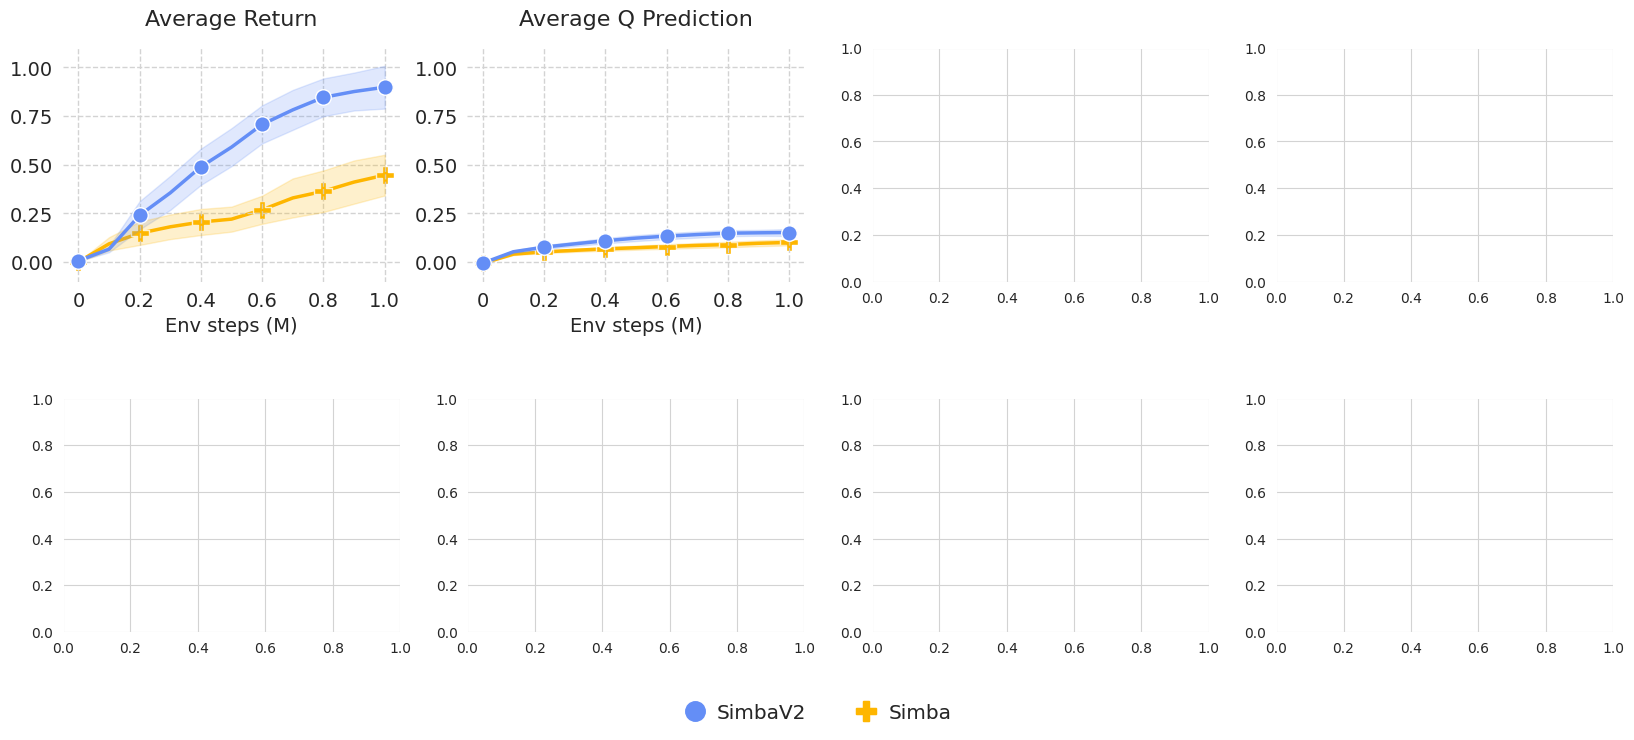

In [25]:
plot_analysis_metrics_total(
    eval_df,
    HB_LOCOMOTION_NOHAND,
    colors,
    metrics=['avg_return', 'avg_estimate_q', 'q_bias', 'q_variance', 'critic/effective_fnorm_total', 'critic/effective_pnorm_total', 'critic/effective_gnorm_total', 'critic/effective_lr_total'],
    metrics_to_title=metrics_to_title,
    bbox_to_anchor=(0.5, 0.015),
    main_title="HB",
    columns=["SimbaV2", "Simba"],
)